<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula16a_clustering_with_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

blob_centers = np.array([[0.2, 2.3], [-1.5, 2.3], [-2.8, 1.8],
                         [-2.8, 2.8], [-2.8, 1.3]])

blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=7)

k = 5
kmeans = KMeans(n_clusters=k, init="random", n_init="auto", random_state=42)
y_pred = kmeans.fit_predict(X)

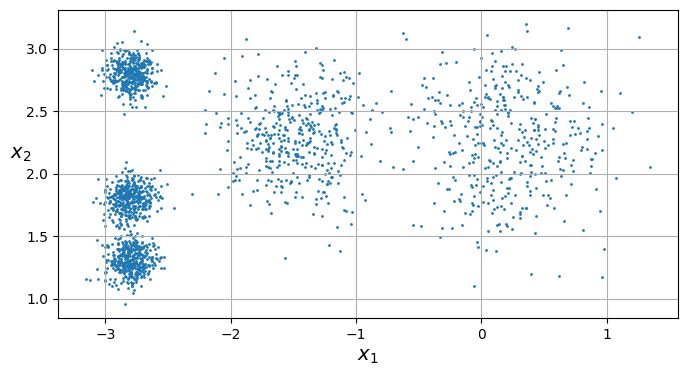

In [6]:
import matplotlib.pyplot as plt

def plot_cluster(X, y=None):
  plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
  plt.xlabel("$x_1$", fontsize=14)
  plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_cluster(X)
plt.grid()
plt.show()

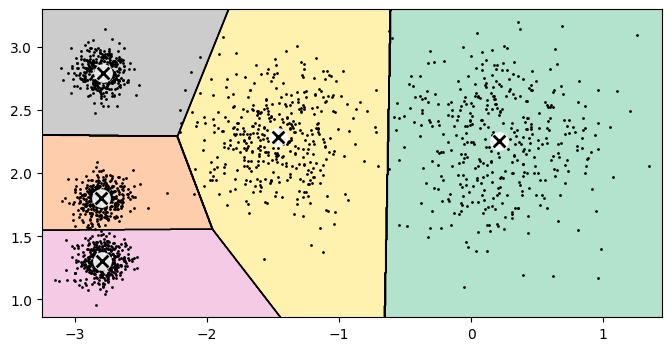

In [7]:
def plot_data(X):
  plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
  if weights is not None:
    centroids = centroids[weights > weights.max() / 10]
  plt.scatter(centroids[:, 0], centroids[:, 1],
              marker='o', s=30, linewidths=8,
              color=circle_color, zorder=10, alpha=0.9)
  plt.scatter(centroids[:, 0], centroids[:, 1],
              marker='x', s=2, linewidths=12,
              color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True):
  mins = X.min(axis=0) - 0.1
  maxs = X.max(axis=0) + 0.1
  xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                       np.linspace(mins[1], maxs[1], resolution))
  Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
               cmap="Pastel2")
  plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
              linewidths=1, colors='k')
  plot_data(X)
  if show_centroids:
    plot_centroids(clusterer.cluster_centers_)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

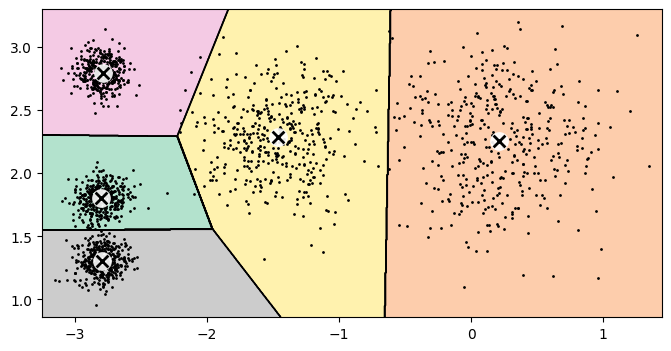

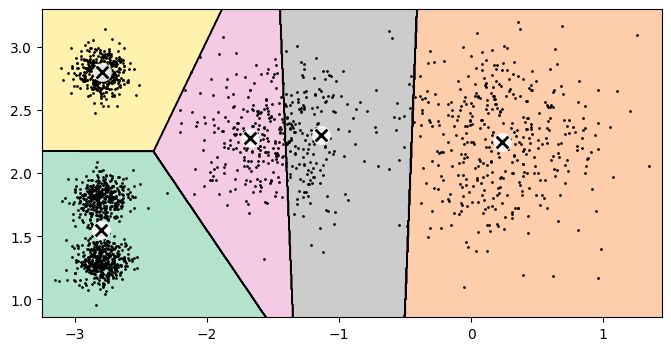

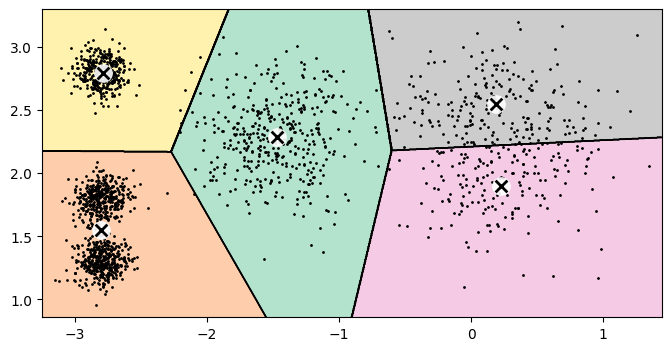

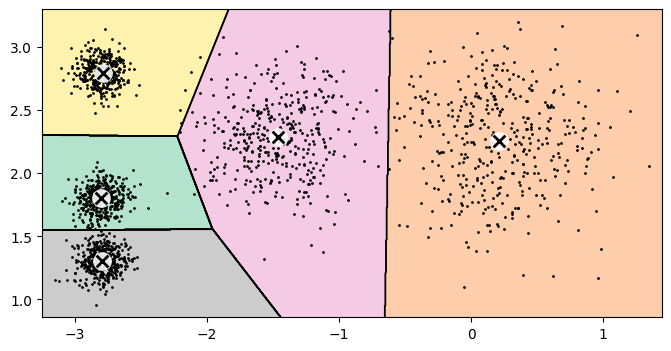

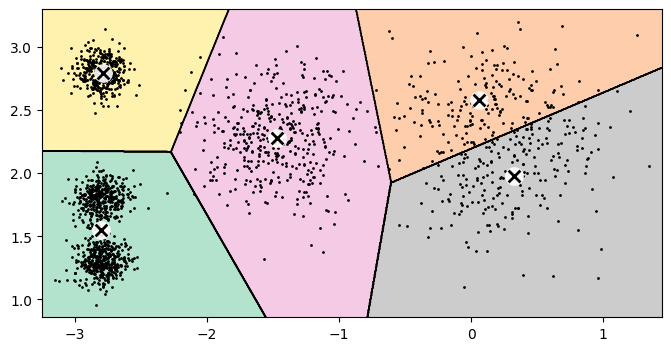

In [9]:
for _ in range(5):
  plt.figure(figsize=(8, 4))
  kmeans = KMeans(n_clusters=5, init="k-means++", n_init="auto")
  y_pred = kmeans.fit_predict(X)
  plot_decision_boundaries(kmeans, X)
  plt.show()

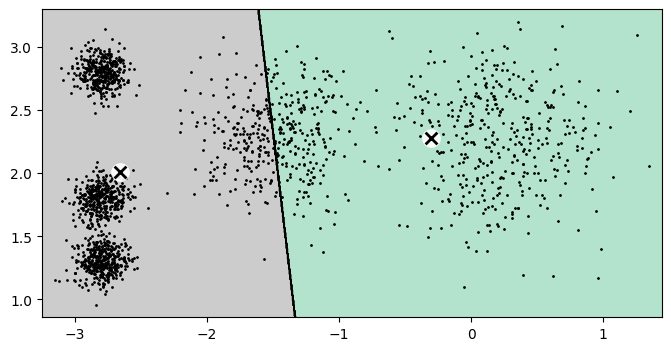

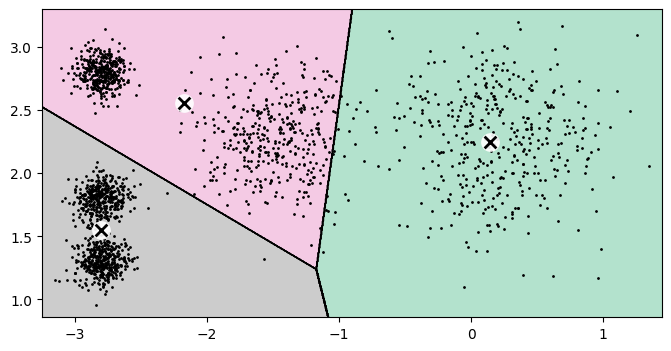

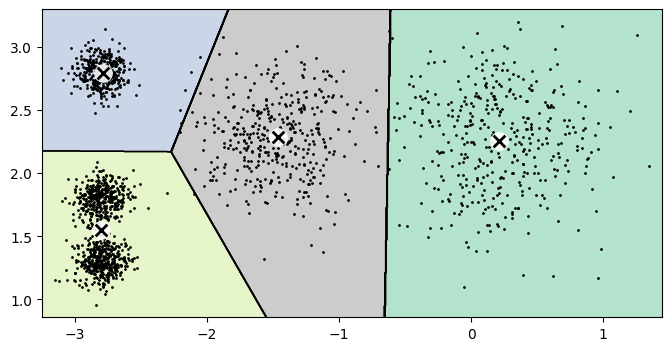

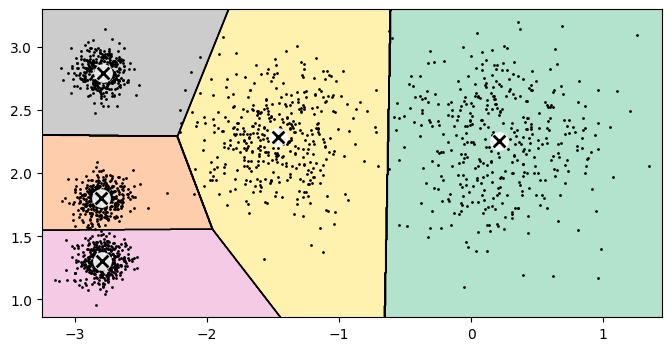

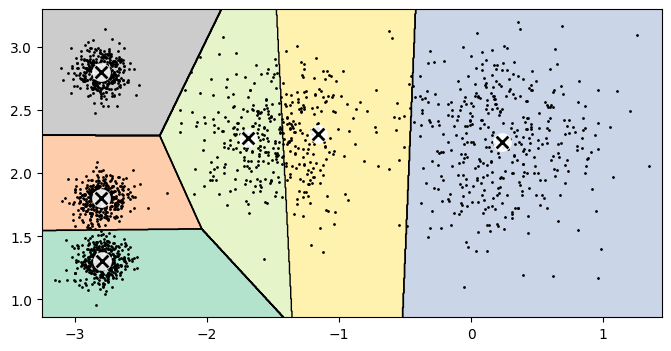

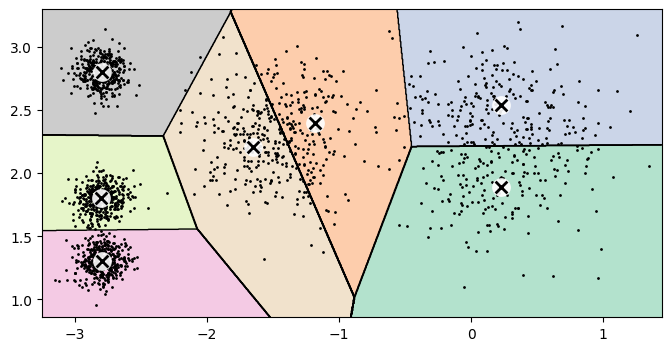

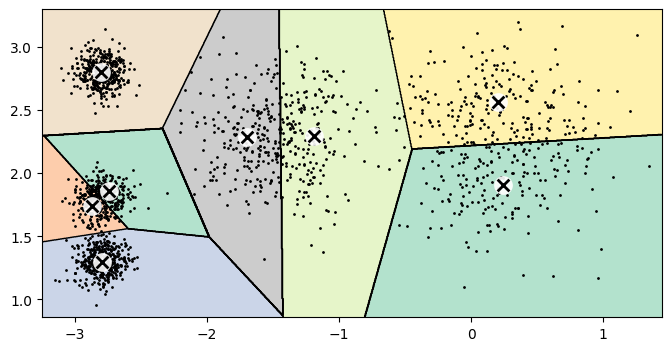

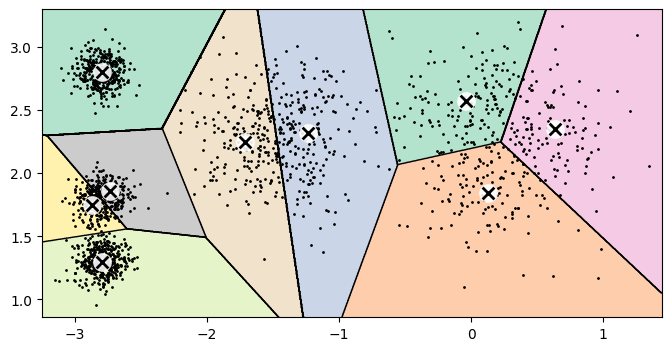

In [11]:
for k in range(2,10):
  kmeans = KMeans(n_clusters=k, init="random", n_init="auto", random_state=42)
  y_pred = kmeans.fit_predict(X)
  plt.figure(figsize=(8, 4))
  plot_decision_boundaries(kmeans, X)

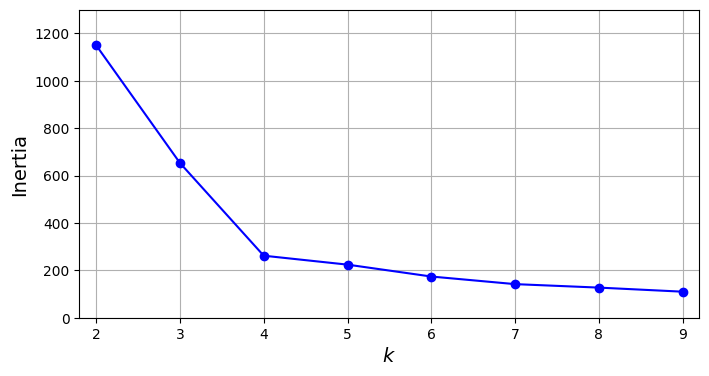

In [13]:
kmeans_per_k = [KMeans(n_clusters=k, n_init="auto", random_state=42).fit(X) for k in range(2,10)]
inertias = [model.inertia_ for model in kmeans_per_k]
plt.figure(figsize=(8, 4))
plt.plot(range(2, 10), inertias, 'bo-')
plt.xlabel('$k$', fontsize=14)
plt.ylabel('Inertia', fontsize=14)
plt.axis([1.8, 9.2, 0, 1300])
plt.grid()
plt.show()

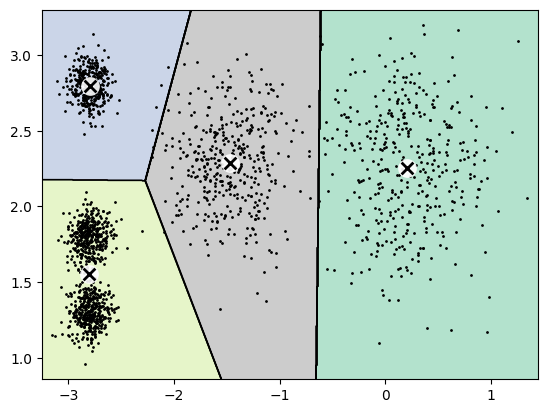

In [14]:
plot_decision_boundaries(kmeans_per_k[4-2], X)
plt.show()